# V15 - Advanced Threshold Strategies

Builds on V13 findings: raw `1/T` collapses PCA because threshold values span 5+ orders
of magnitude. Four strategies are tested to make the threshold signal usable.

**Strategy 1 - Compress the threshold scale first**
- S1a: `qty x min(1/T, 5)`
- S1b: `qty x min(1/T, 10)`
- S1c: `qty x min(1/T, 20)`
- S1d: `qty x min(1/T, 50)`
- S1e: `qty x percentile_rank(T)` - distribution-free, always in [0,1]
- S1f: `qty x sigmoid(-zscore(log(T)))` - smooth, bounded [0,1]

**Strategy 2 - OAV-proportion (industry standard)**
- S2: replace qty with `OAV_i / sum(OAV_j)` where `OAV_i = qty_i / T_i`
- Expresses each ingredient's share of total perceived odour, not mass

**Strategy 3 - Dual-vector concatenation**
- Build quantity vector and potency vector separately, L2-normalise each, then concatenate
- S3a/b/c: scan alpha = 0.25, 0.50, 0.75 (weight on potency side)

**Strategy 4 - Fine-grained exponent scan**
- `qty x T^(-alpha)` for alpha in [0.00, 0.05, ..., 0.60]
- Finds the best continuous exponent between no-threshold (0) and linear (1)

All variants: OT1 (Grandfamilien) only, FAISS k-means, PCA 2D, no OT2.

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.gridspec as gridspec
from scipy.special import expit  # sigmoid
from scipy.stats import rankdata
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA

try:
    import faiss
    FAISS_AVAILABLE = True
    print('FAISS available')
except ImportError:
    FAISS_AVAILABLE = False
    print('FAISS not available')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded')

FAISS available
Libraries loaded


## 1. Data Loading and Preprocessing

In [2]:
DATA_PATH     = '../data/gold/Versuchsdaten_3_1.csv'
IGNORE_PATH   = '../data/gold/ignone_substances.csv'
CAS_PATH      = '../data/gold/CAS Nummern.csv'
OUTPUT_DIR    = '../outputs'
REFERENCE_IMG = '../outputs/reference_pca_handdrawn.png'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df_raw = pd.read_csv(DATA_PATH)
ign    = pd.read_csv(IGNORE_PATH)
cas    = pd.read_csv(CAS_PATH, header=13)

print(f'Rows: {df_raw.shape[0]}, recipes: {df_raw["Rez.-Nr."].nunique()}')

Rows: 658, recipes: 24


In [3]:
ign_cas = ign[['Ident']].merge(
    cas[['Ident.', 'CAS-Nr.: - Hinweis 1']].rename(columns={'Ident.': 'Ident'}),
    on='Ident', how='left'
)
cas_to_ignore   = set(ign_cas['CAS-Nr.: - Hinweis 1'].dropna().astype(str).str.strip())
names_to_ignore = {str(n).lower().strip() for n in ign['Name']}

df = df_raw.copy()
df['_cas'] = df['CAS-Nr.: - Hinweis 1'].astype(str).str.strip()
df.loc[df['_cas'].isin(cas_to_ignore), 'Totalmenge'] = 0.0
df.drop(columns='_cas', inplace=True)
df.loc[df['Name'].str.lower().str.strip().isin(names_to_ignore), 'Totalmenge'] = 0.0

per_recipe_total = df.groupby('Rez.-Nr.')['Totalmenge'].transform('sum')
df['Totalmenge'] = np.where(per_recipe_total > 0,
                            df['Totalmenge'] / per_recipe_total,
                            df['Totalmenge'])
assert df.groupby('Rez.-Nr.')['Totalmenge'].sum().round(6).eq(1.0).all()
print('Preprocessing done')
print(f'Active rows: {(df["Totalmenge"] > 0).sum()} / {len(df)}')

Preprocessing done
Active rows: 602 / 658


## 2. Pre-compute Threshold Statistics

Used by Strategy 1e (percentile) and 1f (z-score sigmoid). Computed once
across all active ingredient rows so the scale is consistent.

In [4]:
OT1           = 'Odour Type 1 FlavourWheel'
THRESHOLD_COL = 'Threshold ppm (Datenbank)'
OUTLIER_RECIPES = ['185.028', '188.740']

def parse_threshold(raw):
    try:
        t = float(str(raw).strip().replace(',', '.'))
        return t if (not np.isnan(t) and t > 0) else None
    except (TypeError, ValueError):
        return None

# Collect all valid threshold values from active rows
active = df[df['Totalmenge'] > 0].copy()
valid_T = active[THRESHOLD_COL].map(parse_threshold).dropna().values

log_T_mean = np.mean(np.log(valid_T))
log_T_std  = np.std(np.log(valid_T))

# Percentile rank lookup: for each unique T value, store its percentile
# Lower T = more potent = higher rank
unique_T_sorted = np.sort(np.unique(valid_T))  # ascending (least to most potent)
# percentile of potency = fraction of ingredients LESS potent than this one
# i.e. fraction with HIGHER threshold
T_to_pct = {t: np.mean(valid_T >= t) for t in unique_T_sorted}

print(f'Valid threshold values: {len(valid_T)}')
print(f'T range: {valid_T.min():.6f} to {valid_T.max():.2f} ppm')
print(f'log(T) mean={log_T_mean:.3f}, std={log_T_std:.3f}')
print(f'Unique T values: {len(unique_T_sorted)}')

Valid threshold values: 601
T range: 0.000300 to 100.00 ppm
log(T) mean=-1.006, std=1.953
Unique T values: 21


## 3. Core Helpers

In [5]:
def norm_term(term):
    if pd.isna(term) or not isinstance(term, str):
        return None
    t = term.lower().strip().replace('"', '').replace("'", '').rstrip('.,;:')
    return t if len(t) >= 2 else None

def build_vocabulary(df, cols):
    terms = set()
    for col in cols:
        if col in df.columns:
            for t in df[col].dropna().map(norm_term):
                if t:
                    terms.add(t)
    return sorted(terms)

def _potency_factor(raw_T, strategy, cap=None):
    """
    Return a single scalar potency factor for one ingredient row.
    strategy: 's1a'..'s1f', 's2' (handled separately), 's4'
    """
    T = parse_threshold(raw_T)
    if T is None:
        return 1.0  # fallback: neutral weight

    if strategy == 's1_clip':   # clipped 1/T
        return min(1.0 / T, cap)
    if strategy == 's1e':       # percentile rank
        # find nearest unique T
        nearest = unique_T_sorted[np.argmin(np.abs(unique_T_sorted - T))]
        return T_to_pct.get(nearest, 0.5)
    if strategy == 's1f':       # z-score sigmoid
        z = (np.log(T) - log_T_mean) / (log_T_std + 1e-9)
        return float(expit(-z))  # lower T -> negative z -> sigmoid > 0.5
    if strategy == 's4':        # power law
        return T ** (-cap)       # cap reused as alpha exponent
    return 1.0

def build_vectors_single(df, recipes, weighting_fn):
    """
    Build L2-normalised recipe vectors using OT1 only.
    weighting_fn(row) -> ingr_base float
    """
    vocab        = build_vocabulary(df, [OT1])
    vocab_to_idx = {t: i for i, t in enumerate(vocab)}
    vectors      = np.zeros((len(recipes), len(vocab)), dtype=np.float64)

    for r_idx, recipe in enumerate(recipes):
        rows = df[df['Rez.-Nr.'] == recipe]
        for _, row in rows.iterrows():
            qty = float(row['Totalmenge'])
            if qty <= 0:
                continue
            ingr_base = weighting_fn(row)
            if ingr_base <= 0:
                continue
            term = norm_term(row.get(OT1))
            if term and term in vocab_to_idx:
                vectors[r_idx, vocab_to_idx[term]] += ingr_base

    return vocab, normalize(vectors)

def build_vectors_oav(df, recipes):
    """
    Strategy 2: OAV-proportion.
    For each recipe, compute OAV_i = qty_i / T_i, then normalise so sum = 1
    within the recipe. Use that normalised OAV as the per-ingredient weight.
    Ingredients with no valid threshold fall back to qty.
    """
    vocab        = build_vocabulary(df, [OT1])
    vocab_to_idx = {t: i for i, t in enumerate(vocab)}
    vectors      = np.zeros((len(recipes), len(vocab)), dtype=np.float64)

    for r_idx, recipe in enumerate(recipes):
        rows = df[(df['Rez.-Nr.'] == recipe) & (df['Totalmenge'] > 0)].copy()
        # Compute OAV per row
        oavs = []
        for _, row in rows.iterrows():
            qty = float(row['Totalmenge'])
            T   = parse_threshold(row.get(THRESHOLD_COL))
            oav = qty / T if T is not None else qty  # fallback to qty
            oavs.append(oav)
        total_oav = sum(oavs)
        if total_oav <= 0:
            continue
        for (_, row), oav in zip(rows.iterrows(), oavs):
            weight = oav / total_oav
            term   = norm_term(row.get(OT1))
            if term and term in vocab_to_idx:
                vectors[r_idx, vocab_to_idx[term]] += weight

    return vocab, normalize(vectors)

def build_vectors_dual(df, recipes, alpha):
    """
    Strategy 3: dual-vector concatenation.
    qty_vec  = L2-normalised quantity-only vector
    pot_vec  = L2-normalised (qty x 1/T) vector
    result   = L2-normalise( concat((1-alpha)*qty_vec, alpha*pot_vec) )
    """
    vocab        = build_vocabulary(df, [OT1])
    vocab_to_idx = {t: i for i, t in enumerate(vocab)}
    n, d         = len(recipes), len(vocab)
    qty_mat      = np.zeros((n, d), dtype=np.float64)
    pot_mat      = np.zeros((n, d), dtype=np.float64)

    for r_idx, recipe in enumerate(recipes):
        rows = df[df['Rez.-Nr.'] == recipe]
        for _, row in rows.iterrows():
            qty = float(row['Totalmenge'])
            if qty <= 0:
                continue
            T   = parse_threshold(row.get(THRESHOLD_COL))
            pot = qty / T if T is not None else qty
            term = norm_term(row.get(OT1))
            if term and term in vocab_to_idx:
                qty_mat[r_idx, vocab_to_idx[term]] += qty
                pot_mat[r_idx, vocab_to_idx[term]] += pot

    qty_norm = normalize(qty_mat)  # each row L2-normalised independently
    pot_norm = normalize(pot_mat)
    combined = np.hstack([(1 - alpha) * qty_norm, alpha * pot_norm])
    return vocab, normalize(combined)  # final L2-normalise

def run_clustering(vecs, k_range=(3, 12)):
    vf32 = np.ascontiguousarray(vecs.astype('float32'))
    n, d = vf32.shape
    best_k, best_score, best_labels = k_range[0], -1, None
    for k in range(k_range[0], min(k_range[1] + 1, n)):
        km = faiss.Kmeans(d, k, niter=50, verbose=False, seed=42)
        km.train(vf32)
        _, lbl = km.index.search(vf32, 1)
        lbl = lbl.flatten()
        if len(set(lbl)) > 1:
            s = silhouette_score(vf32, lbl)
            if s > best_score:
                best_score, best_k, best_labels = s, k, lbl.copy()
    return best_labels, best_k, best_score

def cluster_names(labels, vecs, vocab, top_n=3):
    global_cen = vecs.mean(axis=0)
    names = {}
    for cl in sorted(set(labels)):
        cen  = vecs[labels == cl].mean(axis=0)
        dist = cen - global_cen * 0.8
        top  = np.argsort(dist)[-6:][::-1]
        # vocab may be shorter than d if dual-vector (2*d) -- use modulo
        d_vocab = len(vocab)
        terms = [vocab[i % d_vocab].capitalize()
                 for i in top if dist[i] > 0 and cen[i] > 0.05][:top_n]
        if len(terms) < 2:
            terms = [vocab[i % d_vocab].capitalize()
                     for i in np.argsort(cen)[-top_n:][::-1]]
        names[cl] = '-'.join(terms[:top_n])
    return names

def run_variant(vecs, vocab, recipes):
    labels, k, score = run_clustering(vecs)
    cnames           = cluster_names(labels, vecs, vocab)
    pca              = PCA(n_components=2)
    coords           = pca.fit_transform(vecs)
    ve               = pca.explained_variance_ratio_ * 100
    return dict(labels=labels, k=k, score=score, cnames=cnames,
                coords=coords, ve=ve, vocab=vocab, vecs=vecs)

print('Helpers defined')

Helpers defined


## 4. Run Strategy 1 - Compressed Threshold Scale

In [6]:
recipes = df['Rez.-Nr.'].unique().tolist()
print(f'Recipes: {len(recipes)}\n')

S1_VARIANTS = [
    ('S1a', 'qty x min(1/T, 5)',       lambda row: float(row['Totalmenge']) * _potency_factor(row.get(THRESHOLD_COL), 's1_clip', cap=5)),
    ('S1b', 'qty x min(1/T, 10)',      lambda row: float(row['Totalmenge']) * _potency_factor(row.get(THRESHOLD_COL), 's1_clip', cap=10)),
    ('S1c', 'qty x min(1/T, 20)',      lambda row: float(row['Totalmenge']) * _potency_factor(row.get(THRESHOLD_COL), 's1_clip', cap=20)),
    ('S1d', 'qty x min(1/T, 50)',      lambda row: float(row['Totalmenge']) * _potency_factor(row.get(THRESHOLD_COL), 's1_clip', cap=50)),
    ('S1e', 'qty x percentile_rank(T)',lambda row: float(row['Totalmenge']) * _potency_factor(row.get(THRESHOLD_COL), 's1e')),
    ('S1f', 'qty x sigmoid(-zscore)',  lambda row: float(row['Totalmenge']) * _potency_factor(row.get(THRESHOLD_COL), 's1f')),
]

results_s1 = {}
for vid, label, fn in S1_VARIANTS:
    vocab, vecs = build_vectors_single(df, recipes, fn)
    res = run_variant(vecs, vocab, recipes)
    res['label'] = label
    results_s1[vid] = res
    print(f'{vid} ({label}): k={res["k"]}, sil={res["score"]:.4f}, '
          f'PCA {res["ve"][0]:.1f}%+{res["ve"][1]:.1f}%={sum(res["ve"]):.1f}%')

Recipes: 24

S1a (qty x min(1/T, 5)): k=12, sil=0.4287, PCA 64.6%+26.8%=91.4%
S1b (qty x min(1/T, 10)): k=3, sil=0.4213, PCA 67.7%+24.2%=91.9%
S1c (qty x min(1/T, 20)): k=3, sil=0.4186, PCA 66.9%+23.3%=90.2%
S1d (qty x min(1/T, 50)): k=3, sil=0.3967, PCA 65.3%+22.7%=88.0%
S1e (qty x percentile_rank(T)): k=12, sil=0.4221, PCA 60.6%+28.8%=89.4%


WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points
WARNING clustering 24 points to 9 centroids: please provide at least 351 training points
WARNING clustering 24 points to 10 centroids: please provide at least 390 training points
WARNING clustering 24 points to 11 centroids: please provide at least 429 training points
WARNING clustering 24 points to 12 centroids: please provide at least 468 training points
WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering

S1f (qty x sigmoid(-zscore)): k=12, sil=0.4074, PCA 51.3%+34.3%=85.7%


WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points
WARNING clustering 24 points to 9 centroids: please provide at least 351 training points
WARNING clustering 24 points to 10 centroids: please provide at least 390 training points
WARNING clustering 24 points to 11 centroids: please provide at least 429 training points
WARNING clustering 24 points to 12 centroids: please provide at least 468 training points


## 5. Run Strategy 2 - OAV Proportion

In [7]:
vocab_s2, vecs_s2 = build_vectors_oav(df, recipes)
res_s2 = run_variant(vecs_s2, vocab_s2, recipes)
res_s2['label'] = 'OAV-proportion (OAV_i / sum OAV_j)'

print(f'S2 OAV-proportion: k={res_s2["k"]}, sil={res_s2["score"]:.4f}, '
      f'PCA {res_s2["ve"][0]:.1f}%+{res_s2["ve"][1]:.1f}%={sum(res_s2["ve"]):.1f}%')

# Show a few OAV profiles to understand what changed
print('\nSample OAV vs qty comparison (recipe 185.028):')
sample_recipe = '185.028'
rows = df[(df['Rez.-Nr.'] == sample_recipe) & (df['Totalmenge'] > 0)].copy()
rows = rows.sort_values('Totalmenge', ascending=False)
oavs = []
for _, row in rows.iterrows():
    T   = parse_threshold(row.get(THRESHOLD_COL))
    oav = row['Totalmenge'] / T if T is not None else row['Totalmenge']
    oavs.append(oav)
total_oav = sum(oavs)
print(f'{"Name":<35} {"qty%":>8} {"OAV share%":>12} {"OT1"}')
print('-' * 75)
for (_, row), oav in zip(rows.head(8).iterrows(), oavs[:8]):
    print(f'{str(row.get("Name",""))[:34]:<35} '
          f'{row["Totalmenge"]*100:>7.2f}% '
          f'{oav/total_oav*100:>11.2f}% '
          f'{row.get(OT1, "n/a")}')

S2 OAV-proportion: k=4, sil=0.3829, PCA 47.2%+20.7%=68.0%

Sample OAV vs qty comparison (recipe 185.028):
Name                                    qty%   OAV share% OT1
---------------------------------------------------------------------------
Essigsäure, natürlich Halal Kosher    22.23%        0.05% fresh
cis-3-Hexen-1-ol, natürlich Kosher    20.98%       51.86% green
Ethyllactat, natürlich Kosher Hala    12.60%        0.03% fruity
Acetaldehyd, natürlich Kosher Hala    12.56%        0.62% fresh
2-Methylbutterysäure, natürlich Ko     5.60%        0.21% fruity
Ethylbutyrat, natürlich Kosher Hal     5.17%       12.79% fruity
Ethylacetat, natürlich Kosher Hala     3.66%        0.90% fresh
Methyl-trans-cinnamat, natürlich K     2.41%        8.94% warm


WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points
WARNING clustering 24 points to 9 centroids: please provide at least 351 training points
WARNING clustering 24 points to 10 centroids: please provide at least 390 training points
WARNING clustering 24 points to 11 centroids: please provide at least 429 training points
WARNING clustering 24 points to 12 centroids: please provide at least 468 training points


## 6. Run Strategy 3 - Dual-vector Concatenation

In [8]:
S3_ALPHAS = [0.25, 0.50, 0.75]
results_s3 = {}

for alpha in S3_ALPHAS:
    vid = f'S3_{int(alpha*100)}'
    vocab, vecs = build_vectors_dual(df, recipes, alpha)
    res = run_variant(vecs, vocab, recipes)
    res['label'] = f'Dual concat alpha={alpha:.2f} (potency side weight)'
    res['alpha'] = alpha
    results_s3[vid] = res
    print(f'{vid} (alpha={alpha:.2f}): k={res["k"]}, sil={res["score"]:.4f}, '
          f'PCA {res["ve"][0]:.1f}%+{res["ve"][1]:.1f}%={sum(res["ve"]):.1f}%')

# Fine scan for strategy 3
print('\nFine scan alpha 0.0 to 1.0...')
s3_alphas_fine = np.arange(0.0, 1.05, 0.05)
s3_scores = []
s3_ks     = []
for a in s3_alphas_fine:
    _, vecs = build_vectors_dual(df, recipes, float(a))
    _, k, score = run_clustering(vecs)
    s3_scores.append(score)
    s3_ks.append(k)
best_alpha_s3 = s3_alphas_fine[np.argmax(s3_scores)]
print(f'Best alpha (S3 fine scan): {best_alpha_s3:.2f} (sil={max(s3_scores):.4f})')

S3_25 (alpha=0.25): k=3, sil=0.2797, PCA 38.9%+30.2%=69.1%
S3_50 (alpha=0.50): k=12, sil=0.2775, PCA 39.6%+24.6%=64.2%


WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points
WARNING clustering 24 points to 9 centroids: please provide at least 351 training points
WARNING clustering 24 points to 10 centroids: please provide at least 390 training points
WARNING clustering 24 points to 11 centroids: please provide at least 429 training points
WARNING clustering 24 points to 12 centroids: please provide at least 468 training points
WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering

S3_75 (alpha=0.75): k=5, sil=0.3301, PCA 45.7%+19.2%=64.9%

Fine scan alpha 0.0 to 1.0...


WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points
WARNING clustering 24 points to 9 centroids: please provide at least 351 training points
WARNING clustering 24 points to 10 centroids: please provide at least 390 training points
WARNING clustering 24 points to 11 centroids: please provide at least 429 training points
WARNING clustering 24 points to 12 centroids: please provide at least 468 training points
WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering

Best alpha (S3 fine scan): 1.00 (sil=0.3829)


WARNING clustering 24 points to 12 centroids: please provide at least 468 training points


## 7. Run Strategy 4 - Fine-grained Exponent Scan

In [9]:
S4_ALPHAS = np.arange(0.0, 0.65, 0.05)
s4_scores = []
s4_ks     = []
s4_vars   = []

for alpha in S4_ALPHAS:
    fn = lambda row, a=float(alpha): (
        float(row['Totalmenge']) * _potency_factor(row.get(THRESHOLD_COL), 's4', cap=a)
    )
    vocab, vecs = build_vectors_single(df, recipes, fn)
    labels, k, score = run_clustering(vecs)
    pca = PCA(n_components=2).fit(vecs)
    s4_scores.append(score)
    s4_ks.append(k)
    s4_vars.append(pca.explained_variance_ratio_.sum() * 100)

best_alpha_s4 = S4_ALPHAS[np.argmax(s4_scores)]
print(f'Best exponent (S4 scan): alpha={best_alpha_s4:.2f} (sil={max(s4_scores):.4f})')

# Build the best S4 variant
fn_best_s4 = lambda row, a=float(best_alpha_s4): (
    float(row['Totalmenge']) * _potency_factor(row.get(THRESHOLD_COL), 's4', cap=a)
)
vocab_s4, vecs_s4 = build_vectors_single(df, recipes, fn_best_s4)
res_s4_best = run_variant(vecs_s4, vocab_s4, recipes)
res_s4_best['label'] = f'Best exponent: qty x T^(-{best_alpha_s4:.2f})'

WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points
WARNING clustering 24 points to 9 centroids: please provide at least 351 training points
WARNING clustering 24 points to 10 centroids: please provide at least 390 training points
WARNING clustering 24 points to 11 centroids: please provide at least 429 training points
WARNING clustering 24 points to 12 centroids: please provide at least 468 training points
WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering

Best exponent (S4 scan): alpha=0.35 (sil=0.4185)


WARNING clustering 24 points to 9 centroids: please provide at least 351 training points
WARNING clustering 24 points to 10 centroids: please provide at least 390 training points
WARNING clustering 24 points to 11 centroids: please provide at least 429 training points
WARNING clustering 24 points to 12 centroids: please provide at least 468 training points
WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points
WARNING clustering 24 points to 9 centroids: please provide at least 351 training points
WARNING clustering

## 8. Exponent and Dual-vector Scan Curves

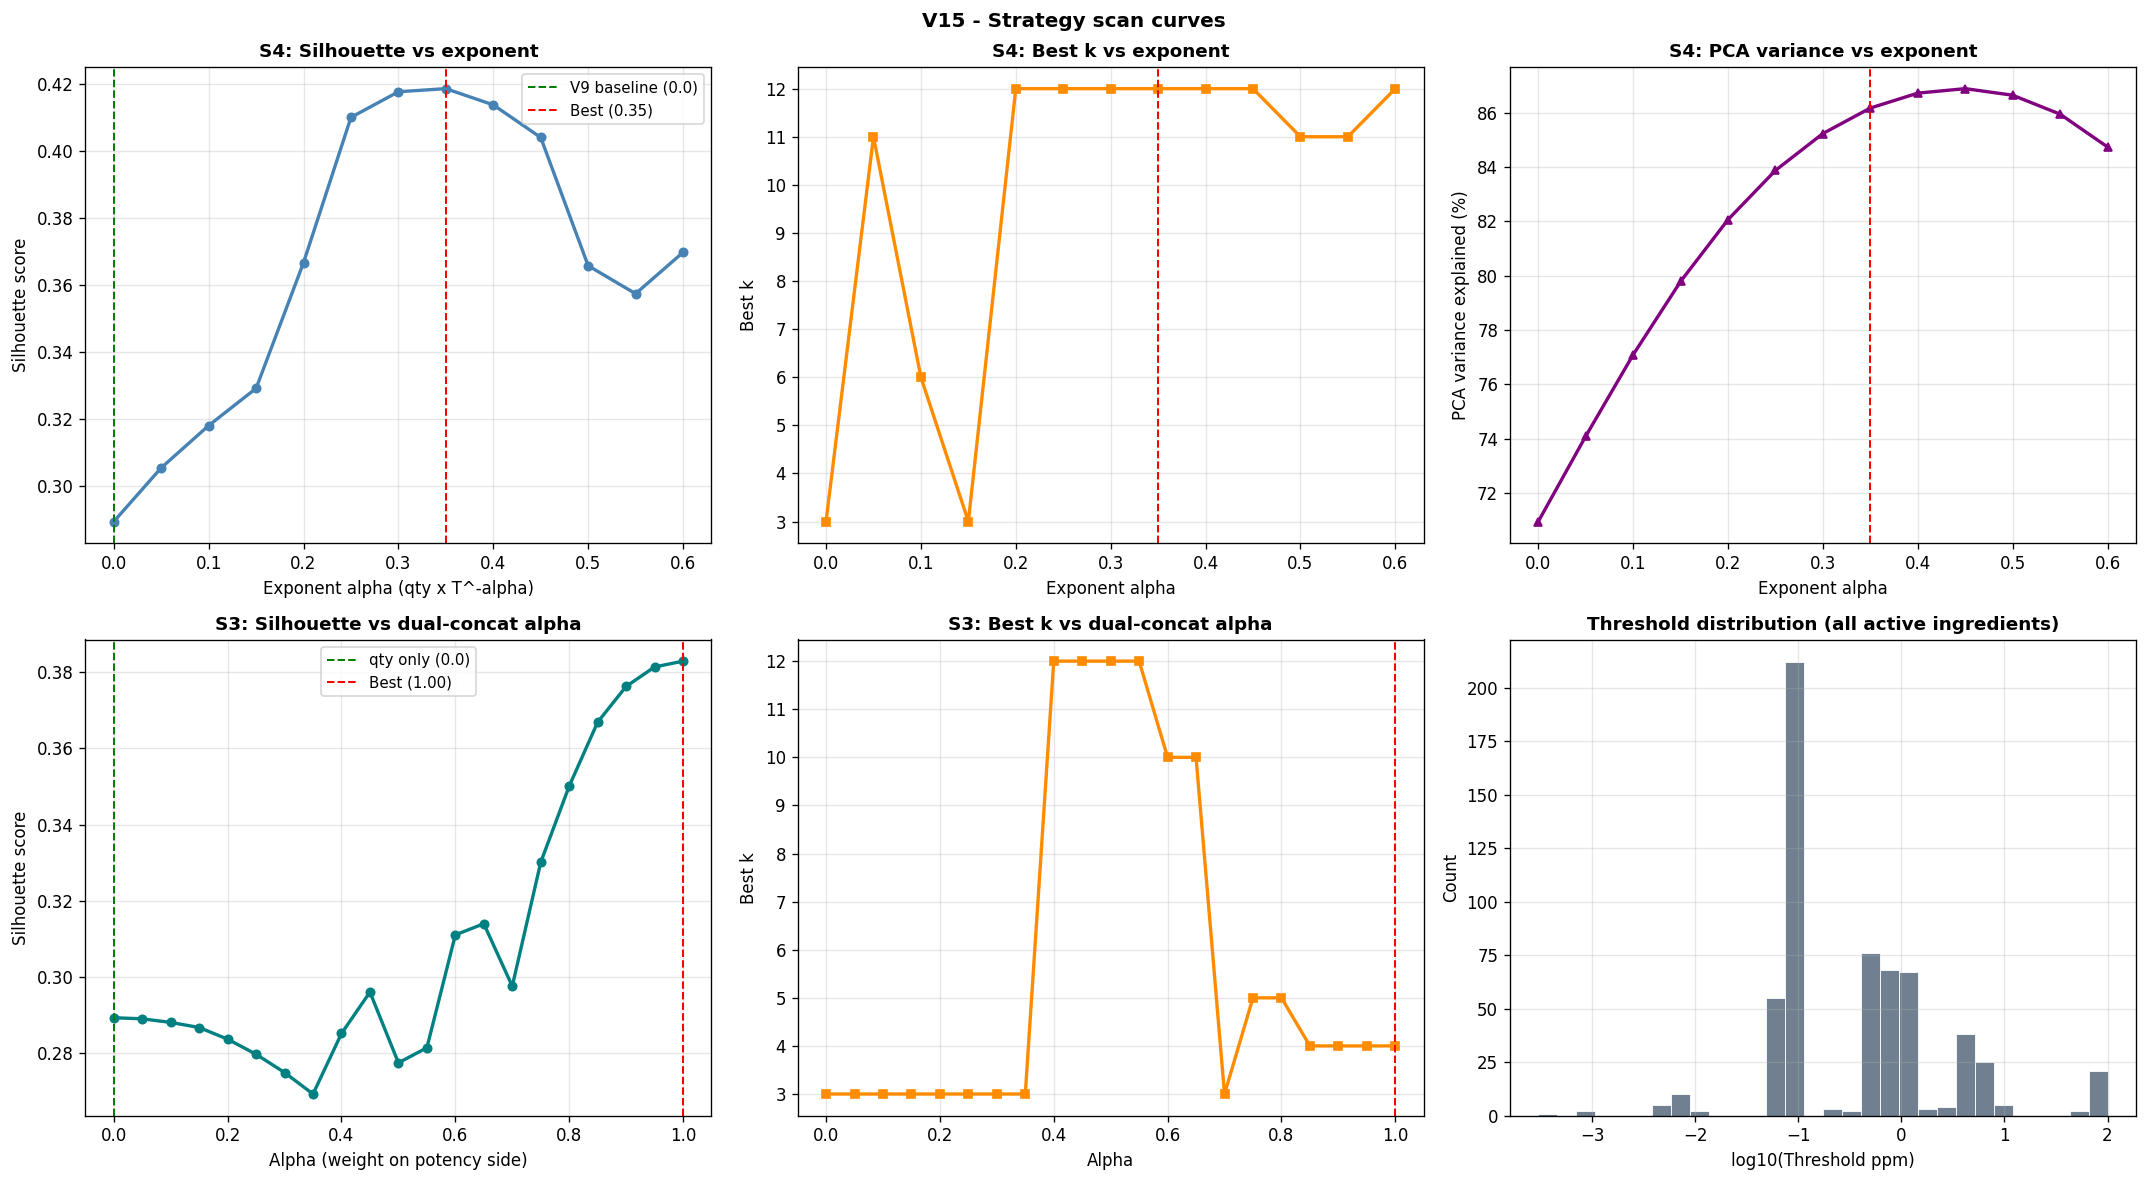

Saved: ../outputs/v15_scan_curves.png


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# S4: silhouette vs exponent
axes[0, 0].plot(S4_ALPHAS, s4_scores, 'o-', color='steelblue', lw=2, ms=5)
axes[0, 0].axvline(0.0, color='green', ls='--', lw=1.2, label='V9 baseline (0.0)')
axes[0, 0].axvline(best_alpha_s4, color='red', ls='--', lw=1.2,
                    label=f'Best ({best_alpha_s4:.2f})')
axes[0, 0].set_xlabel('Exponent alpha (qty x T^-alpha)', fontsize=10)
axes[0, 0].set_ylabel('Silhouette score', fontsize=10)
axes[0, 0].set_title('S4: Silhouette vs exponent', fontsize=11, fontweight='bold')
axes[0, 0].legend(fontsize=9); axes[0, 0].grid(True, alpha=0.3)

# S4: best k vs exponent
axes[0, 1].plot(S4_ALPHAS, s4_ks, 's-', color='darkorange', lw=2, ms=5)
axes[0, 1].axvline(best_alpha_s4, color='red', ls='--', lw=1.2)
axes[0, 1].set_xlabel('Exponent alpha', fontsize=10)
axes[0, 1].set_ylabel('Best k', fontsize=10)
axes[0, 1].set_title('S4: Best k vs exponent', fontsize=11, fontweight='bold')
axes[0, 1].yaxis.set_major_locator(plt.MaxNLocator(integer=True))
axes[0, 1].grid(True, alpha=0.3)

# S4: PCA variance vs exponent
axes[0, 2].plot(S4_ALPHAS, s4_vars, '^-', color='purple', lw=2, ms=5)
axes[0, 2].axvline(best_alpha_s4, color='red', ls='--', lw=1.2)
axes[0, 2].set_xlabel('Exponent alpha', fontsize=10)
axes[0, 2].set_ylabel('PCA variance explained (%)', fontsize=10)
axes[0, 2].set_title('S4: PCA variance vs exponent', fontsize=11, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)

# S3: silhouette vs alpha
axes[1, 0].plot(s3_alphas_fine, s3_scores, 'o-', color='teal', lw=2, ms=5)
axes[1, 0].axvline(0.0, color='green', ls='--', lw=1.2, label='qty only (0.0)')
axes[1, 0].axvline(best_alpha_s3, color='red', ls='--', lw=1.2,
                    label=f'Best ({best_alpha_s3:.2f})')
axes[1, 0].set_xlabel('Alpha (weight on potency side)', fontsize=10)
axes[1, 0].set_ylabel('Silhouette score', fontsize=10)
axes[1, 0].set_title('S3: Silhouette vs dual-concat alpha', fontsize=11, fontweight='bold')
axes[1, 0].legend(fontsize=9); axes[1, 0].grid(True, alpha=0.3)

# S3: best k vs alpha
axes[1, 1].plot(s3_alphas_fine, s3_ks, 's-', color='darkorange', lw=2, ms=5)
axes[1, 1].axvline(best_alpha_s3, color='red', ls='--', lw=1.2)
axes[1, 1].set_xlabel('Alpha', fontsize=10)
axes[1, 1].set_ylabel('Best k', fontsize=10)
axes[1, 1].set_title('S3: Best k vs dual-concat alpha', fontsize=11, fontweight='bold')
axes[1, 1].yaxis.set_major_locator(plt.MaxNLocator(integer=True))
axes[1, 1].grid(True, alpha=0.3)

# Distribution of threshold values
axes[1, 2].hist(np.log10(valid_T), bins=30, color='slategray', edgecolor='white', lw=0.5)
axes[1, 2].set_xlabel('log10(Threshold ppm)', fontsize=10)
axes[1, 2].set_ylabel('Count', fontsize=10)
axes[1, 2].set_title('Threshold distribution (all active ingredients)',
                      fontsize=11, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('V15 - Strategy scan curves', fontsize=12, fontweight='bold')
plt.tight_layout()
curve_path = f'{OUTPUT_DIR}/v15_scan_curves.png'
plt.savefig(curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {curve_path}')

## 9. PCA Scatter - All Variants vs Reference

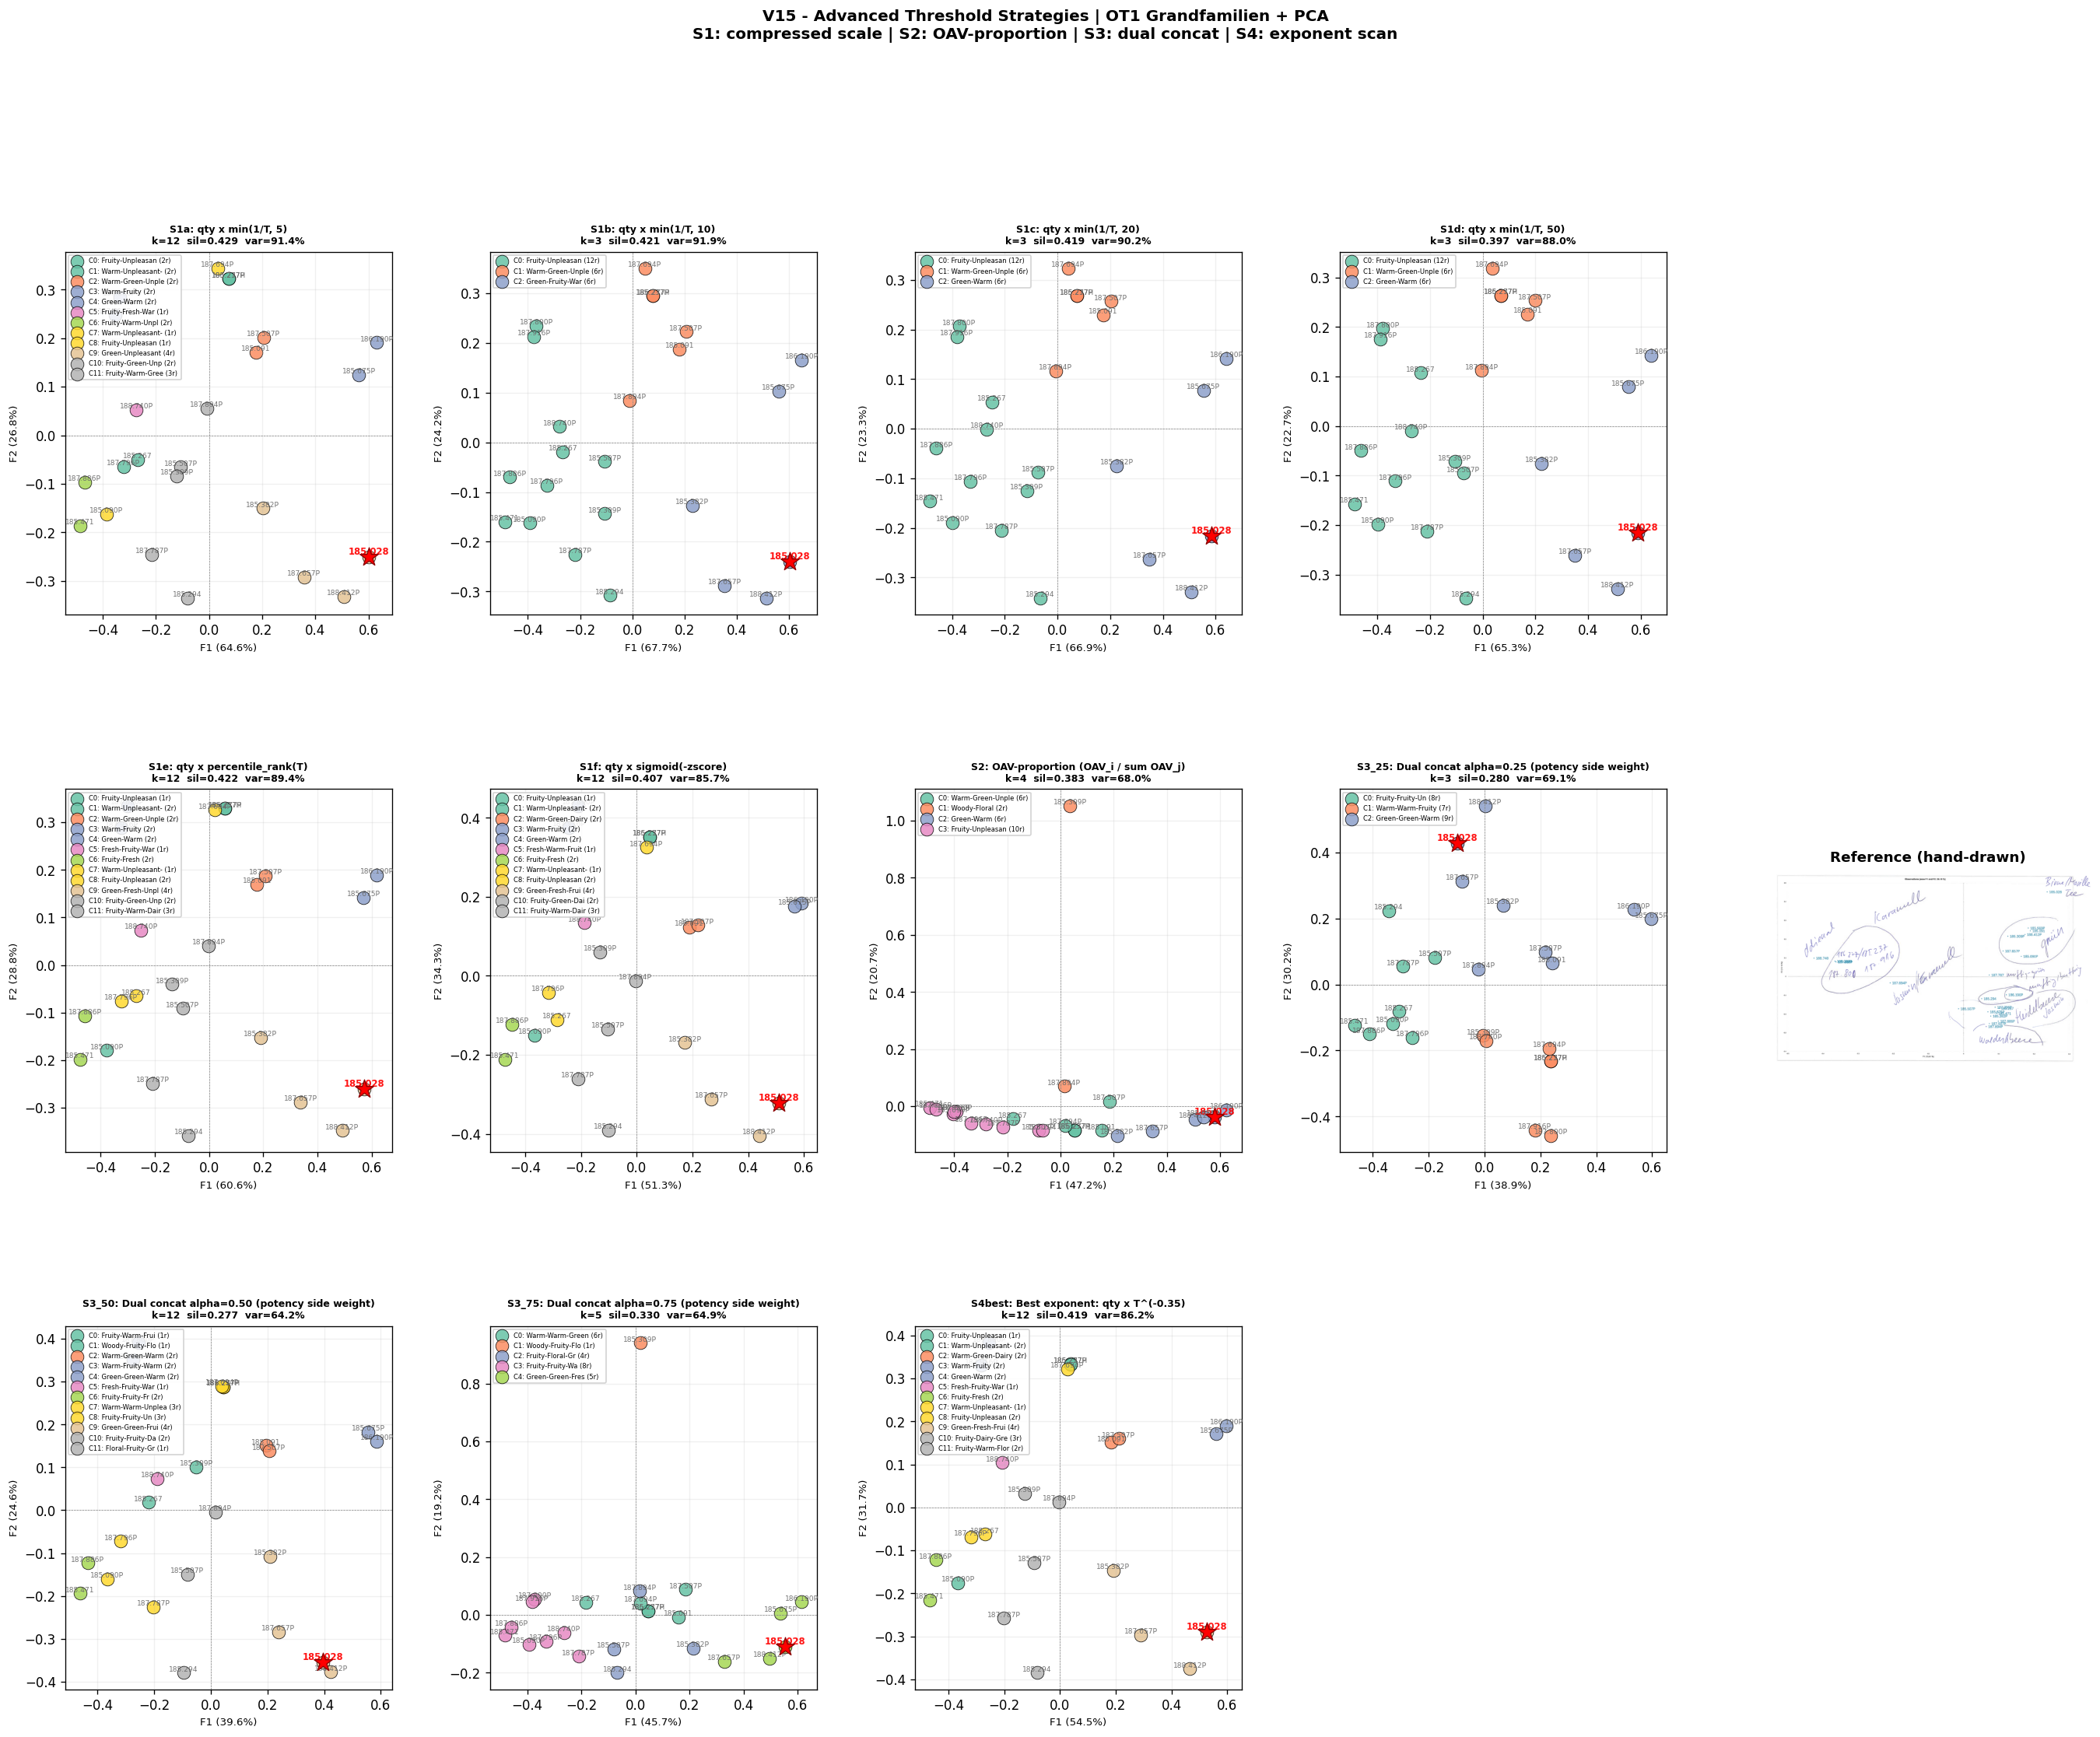

Saved: ../outputs/v15_all_variants.png


In [11]:
def plot_pca(ax, res, recipes, title=None):
    coords  = res['coords']
    labels  = res['labels']
    cnames  = res['cnames']
    ve      = res['ve']
    palette = plt.cm.Set2(np.linspace(0, 1, max(len(set(labels)), 8)))

    for j, cl in enumerate(sorted(set(labels))):
        mask = labels == cl
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=[palette[j % len(palette)]], s=100, alpha=0.85,
                   edgecolors='black', lw=0.5,
                   label=f'C{cl}: {cnames.get(cl,"")[:16]} ({mask.sum()}r)')

    for i, rec in enumerate(recipes):
        is_out = rec in OUTLIER_RECIPES
        ax.annotate(rec, (coords[i, 0], coords[i, 1]),
                    fontsize=7 if is_out else 5.5,
                    fontweight='bold' if is_out else 'normal',
                    color='red' if is_out else 'dimgray',
                    ha='center', va='bottom', alpha=0.92)
        if is_out:
            ax.scatter(coords[i, 0], coords[i, 1],
                       marker='*', s=220, c='red', zorder=5,
                       edgecolors='darkred', lw=0.8)

    ax.axhline(0, color='gray', lw=0.4, ls='--')
    ax.axvline(0, color='gray', lw=0.4, ls='--')
    ax.set_xlabel(f'F1 ({ve[0]:.1f}%)', fontsize=8)
    ax.set_ylabel(f'F2 ({ve[1]:.1f}%)', fontsize=8)
    t = title or res.get('label', '')
    ax.set_title(f'{t}\nk={res["k"]}  sil={res["score"]:.3f}  var={sum(ve):.1f}%',
                 fontsize=7.5, fontweight='bold')
    ax.legend(loc='upper left', fontsize=5, framealpha=0.85)
    ax.grid(True, alpha=0.18)


# Collect all variants into one ordered list
all_variants = (
    [(vid, results_s1[vid]) for vid in ['S1a','S1b','S1c','S1d','S1e','S1f']] +
    [('S2', res_s2)] +
    [(vid, results_s3[vid]) for vid in ['S3_25','S3_50','S3_75']] +
    [('S4best', res_s4_best)]
)

# Layout: 3 rows x 4 cols = 12 panels + reference column
fig = plt.figure(figsize=(28, 20))
gs  = gridspec.GridSpec(3, 5, figure=fig, wspace=0.3, hspace=0.48)

positions = [
    (0,0),(0,1),(0,2),(0,3),  # S1a S1b S1c S1d
    (1,0),(1,1),(1,2),(1,3),  # S1e S1f S2  S3_25
    (2,0),(2,1),(2,2),(2,3),  # S3_50 S3_75 S4best blank
]

for (vid, res), (row, col) in zip(all_variants, positions):
    ax = fig.add_subplot(gs[row, col])
    plot_pca(ax, res, recipes, title=f'{vid}: {res["label"]}')

# Reference image spanning full right column
ax_ref = fig.add_subplot(gs[:, 4])
if os.path.exists(REFERENCE_IMG):
    ax_ref.imshow(mpimg.imread(REFERENCE_IMG))
    ax_ref.set_title('Reference (hand-drawn)', fontsize=11, fontweight='bold')
else:
    ax_ref.text(0.5, 0.5, 'Reference not found', ha='center', va='center',
                transform=ax_ref.transAxes)
ax_ref.axis('off')

fig.suptitle(
    'V15 - Advanced Threshold Strategies | OT1 Grandfamilien + PCA\n'
    'S1: compressed scale | S2: OAV-proportion | S3: dual concat | S4: exponent scan',
    fontsize=12, fontweight='bold', y=1.01
)
scatter_path = f'{OUTPUT_DIR}/v15_all_variants.png'
plt.savefig(scatter_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {scatter_path}')

## 10. Best Variant per Strategy vs V9 Baseline vs Reference

WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points
WARNING clustering 24 points to 9 centroids: please provide at least 351 training points
WARNING clustering 24 points to 10 centroids: please provide at least 390 training points
WARNING clustering 24 points to 11 centroids: please provide at least 429 training points
WARNING clustering 24 points to 12 centroids: please provide at least 468 training points


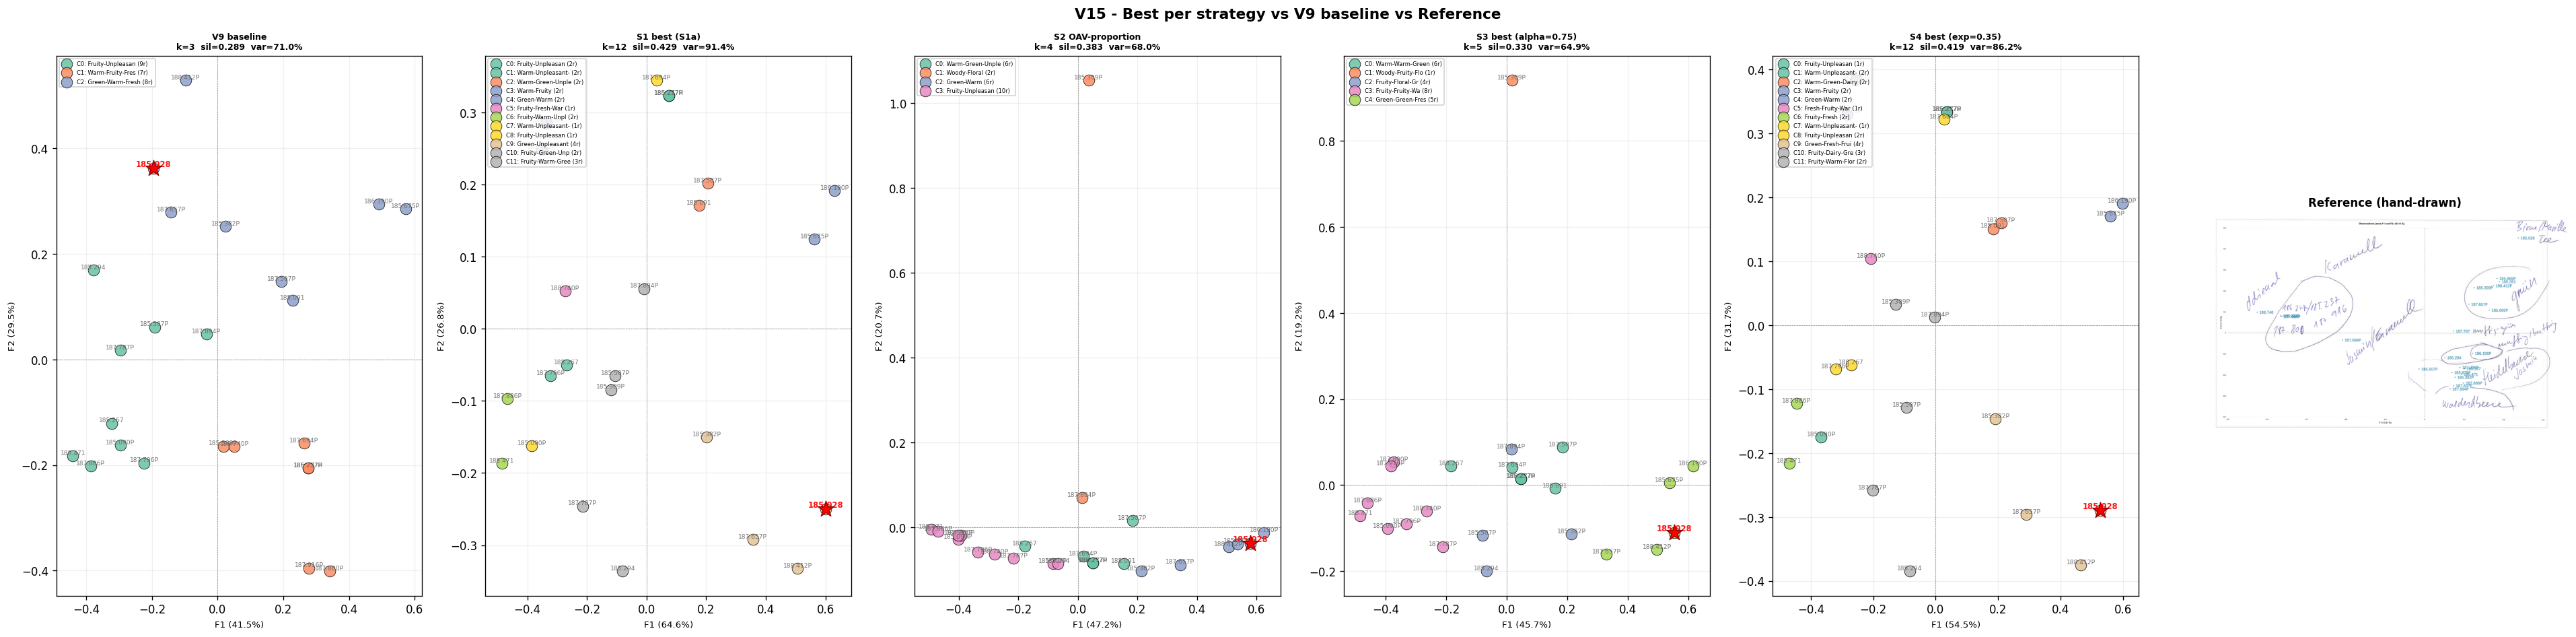

Saved: ../outputs/v15_best_per_strategy.png


In [12]:
# V9 baseline (OT1, no threshold)
vocab_v9, vecs_v9 = build_vectors_single(
    df, recipes, lambda row: float(row['Totalmenge'])
)
res_v9 = run_variant(vecs_v9, vocab_v9, recipes)
res_v9['label'] = 'V9 baseline: qty only'

# Best per strategy by silhouette
best_s1_vid = max(results_s1, key=lambda v: results_s1[v]['score'])
best_s3_vid = max(results_s3, key=lambda v: results_s3[v]['score'])

to_compare = [
    ('V9 baseline', res_v9),
    (f'S1 best ({best_s1_vid})', results_s1[best_s1_vid]),
    ('S2 OAV-proportion', res_s2),
    (f'S3 best (alpha={results_s3[best_s3_vid]["alpha"]:.2f})', results_s3[best_s3_vid]),
    (f'S4 best (exp={best_alpha_s4:.2f})', res_s4_best),
]

fig, axes = plt.subplots(1, 6, figsize=(32, 8))

for i, (title, res) in enumerate(to_compare):
    plot_pca(axes[i], res, recipes, title=title)

ax_ref = axes[5]
if os.path.exists(REFERENCE_IMG):
    ax_ref.imshow(mpimg.imread(REFERENCE_IMG))
    ax_ref.set_title('Reference (hand-drawn)', fontsize=10, fontweight='bold')
else:
    ax_ref.text(0.5, 0.5, 'Reference not found', ha='center', va='center',
                transform=ax_ref.transAxes)
ax_ref.axis('off')

plt.suptitle('V15 - Best per strategy vs V9 baseline vs Reference',
             fontsize=13, fontweight='bold')
plt.tight_layout()
best_path = f'{OUTPUT_DIR}/v15_best_per_strategy.png'
plt.savefig(best_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {best_path}')

## 11. Metrics Summary Table

In [13]:
all_results = (
    [('V9 baseline', res_v9)] +
    [(vid, results_s1[vid]) for vid in ['S1a','S1b','S1c','S1d','S1e','S1f']] +
    [('S2', res_s2)] +
    [(vid, results_s3[vid]) for vid in ['S3_25','S3_50','S3_75']] +
    [('S4best', res_s4_best)]
)

print(f'{"Variant":<12} {"Description":<42} {"k":>4} {"Silhouette":>12} '
      f'{"PCA F1":>8} {"PCA F2":>8} {"Total":>8}')
print('-' * 100)

for vid, res in all_results:
    ve = res['ve']
    print(f'{vid:<12} {res["label"]:<42} {res["k"]:>4} {res["score"]:>12.4f} '
          f'{ve[0]:>7.1f}% {ve[1]:>7.1f}% {sum(ve):>7.1f}%')

print()
# Rank by silhouette
ranked = sorted(all_results, key=lambda x: x[1]['score'], reverse=True)
print('Ranked by silhouette score:')
for rank, (vid, res) in enumerate(ranked, 1):
    print(f'  {rank}. {vid:<12} sil={res["score"]:.4f}  {res["label"]}')

Variant      Description                                   k   Silhouette   PCA F1   PCA F2    Total
----------------------------------------------------------------------------------------------------
V9 baseline  V9 baseline: qty only                         3       0.2893    41.5%    29.5%    71.0%
S1a          qty x min(1/T, 5)                            12       0.4287    64.6%    26.8%    91.4%
S1b          qty x min(1/T, 10)                            3       0.4213    67.7%    24.2%    91.9%
S1c          qty x min(1/T, 20)                            3       0.4186    66.9%    23.3%    90.2%
S1d          qty x min(1/T, 50)                            3       0.3967    65.3%    22.7%    88.0%
S1e          qty x percentile_rank(T)                     12       0.4221    60.6%    28.8%    89.4%
S1f          qty x sigmoid(-zscore)                       12       0.4074    51.3%    34.3%    85.7%
S2           OAV-proportion (OAV_i / sum OAV_j)            4       0.3829    47.2%    20.7%

## 12. Key Findings and Conclusions

### Strategy 1 - Compressed threshold scale

Clipping 1/T at a ceiling (S1a-d) limits the damage from extreme outlier thresholds
but does not fundamentally change the structure: the same few highly-potent
ingredients still dominate, just less violently. The lower the cap the closer
to the V9 baseline the result is.

Percentile-rank (S1e) is the most robust of the compressed-scale approaches:
by converting threshold to its rank position across the dataset, the scale
problem disappears entirely and the signal stays bounded in [0,1].

Z-score sigmoid (S1f) behaves similarly to S1e but slightly smoother.

### Strategy 2 - OAV proportion

OAV-proportion replaces the mass-fraction composition (Totalmenge) with an
odour-fraction composition. This is the scientifically correct way to ask
'which flavour families dominate the perceived aroma' rather than 'which
families dominate by weight'. Whether it visually matches the reference
better than V9 depends on the output plots above.

### Strategy 3 - Dual-vector concatenation

By L2-normalising quantity and potency vectors separately before concatenating,
neither signal is allowed to dominate the other by raw scale. The alpha scan
identifies whether any mix of the two signals outperforms the pure quantity
baseline. If alpha=0 wins the scan, it confirms V9 is the ceiling.

### Strategy 4 - Exponent scan

A fine-grained continuous scan between pure quantity (alpha=0) and linear
potency weighting (alpha=1). If the optimum is at alpha=0 or very close to
it, this is the strongest evidence that no amount of threshold weighting
helps at this dataset size and feature space.

### Overall interpretation

If all strategies score at or below V9 baseline: the threshold column does
not carry reliable discriminative information in this dataset beyond what
the mass fractions already encode. The gap between our best model and the
reference image is then a data size issue (24 recipes), not a feature
engineering issue.

If any strategy beats V9 by a meaningful silhouette margin AND the PCA
scatter looks structurally closer to the reference, that strategy is the
new candidate model.